In [1]:
#Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading Dataset
data = pd.read_csv("autos.csv", encoding="Latin-1")
df = data.copy()
df.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,odometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-26 17:47:46,Peugeot_807_160_NAVTECH_ON_BOARD,privat,Angebot,"$5,000",control,bus,2004,manuell,158,andere,"150,000km",3,lpg,peugeot,nein,2016-03-26 00:00:00,0,79588,2016-04-06 06:45:54
1,2016-04-04 13:38:56,BMW_740i_4_4_Liter_HAMANN_UMBAU_Mega_Optik,privat,Angebot,"$8,500",control,limousine,1997,automatik,286,7er,"150,000km",6,benzin,bmw,nein,2016-04-04 00:00:00,0,71034,2016-04-06 14:45:08
2,2016-03-26 18:57:24,Volkswagen_Golf_1.6_United,privat,Angebot,"$8,990",test,limousine,2009,manuell,102,golf,"70,000km",7,benzin,volkswagen,nein,2016-03-26 00:00:00,0,35394,2016-04-06 20:15:37
3,2016-03-12 16:58:10,Smart_smart_fortwo_coupe_softouch/F1/Klima/Pan...,privat,Angebot,"$4,350",control,kleinwagen,2007,automatik,71,fortwo,"70,000km",6,benzin,smart,nein,2016-03-12 00:00:00,0,33729,2016-03-15 03:16:28
4,2016-04-01 14:38:50,Ford_Focus_1_6_Benzin_TÜV_neu_ist_sehr_gepfleg...,privat,Angebot,"$1,350",test,kombi,2003,manuell,0,focus,"150,000km",7,benzin,ford,nein,2016-04-01 00:00:00,0,39218,2016-04-01 14:38:50


# Data Cleaning

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   dateCrawled          50000 non-null  str  
 1   name                 50000 non-null  str  
 2   seller               50000 non-null  str  
 3   offerType            50000 non-null  str  
 4   price                50000 non-null  str  
 5   abtest               50000 non-null  str  
 6   vehicleType          44905 non-null  str  
 7   yearOfRegistration   50000 non-null  int64
 8   gearbox              47320 non-null  str  
 9   powerPS              50000 non-null  int64
 10  model                47242 non-null  str  
 11  odometer             50000 non-null  str  
 12  monthOfRegistration  50000 non-null  int64
 13  fuelType             45518 non-null  str  
 14  brand                50000 non-null  str  
 15  notRepairedDamage    40171 non-null  str  
 16  dateCreated          50000 non-nu

In [4]:
column_mapping = {
    'dateCrawled': 'date_crawled',
    'offerType': 'offer_type',
    'vehicleType': 'vehicle_type',
    'yearOfRegistration': 'registration_year',
    'powerPS': 'power_ps',
    'monthOfRegistration': 'registration_month',
    'fuelType': 'fuel_type',
    'notRepairedDamage': 'unrepaired_damage',
    'dateCreated': 'date_created',
    'nrOfPictures': 'num_pictures',
    'postalCode': 'postal_code',
    'lastSeen': 'last_seen'
}
df.rename(columns=column_mapping, inplace=True)

In [5]:
df.columns

Index(['date_crawled', 'name', 'seller', 'offer_type', 'price', 'abtest',
       'vehicle_type', 'registration_year', 'gearbox', 'power_ps', 'model',
       'odometer', 'registration_month', 'fuel_type', 'brand',
       'unrepaired_damage', 'date_created', 'num_pictures', 'postal_code',
       'last_seen'],
      dtype='str')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["price"] = pd.to_numeric(df["price"].str.replace(r"[\$,]", "", regex=True), errors='coerce')

In [8]:
df["odometer"] = pd.to_numeric(df["odometer"].str.replace(r"km|,", "", regex=True), errors='coerce')

In [9]:
df.describe()

,price,registration_year,power_ps,odometer,registration_month,num_pictures,postal_code
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.0,50000.000000
mean,9.840044e+03,2005.073280,116.355920,125732.700000,5.723360,0.0,50813.627300
std,4.811044e+05,105.712813,209.216627,40042.211706,3.711984,0.0,25779.747957
min,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1.100000e+03,1999.000000,70.000000,125000.000000,3.000000,0.0,30451.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,0.0,49577.000000
75%,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,0.0,71540.000000
max,1.000000e+08,9999.000000,17700.000000,150000.000000,12.000000,0.0,99998.000000


In [10]:
df.isnull().sum()

date_crawled             0
name                     0
seller                   0
offer_type               0
price                    0
abtest                   0
vehicle_type          5095
registration_year        0
gearbox               2680
power_ps                 0
model                 2758
odometer                 0
registration_month       0
fuel_type             4482
brand                    0
unrepaired_damage     9829
date_created             0
num_pictures             0
postal_code              0
last_seen                0
dtype: int64

In [11]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()} \n")

date_crawled : 48213 

name : 38754 

seller : 2 

offer_type : 2 

price : 2357 

abtest : 2 

vehicle_type : 8 

registration_year : 97 

gearbox : 2 

power_ps : 448 

model : 245 

odometer : 13 

registration_month : 13 

fuel_type : 7 

brand : 40 

unrepaired_damage : 2 

date_created : 76 

num_pictures : 1 

postal_code : 7014 

last_seen : 39481 



In [12]:
for column in df[[col for col in df.columns if (df[col].nunique() < 3) ]].columns:
    print(f"{column} : {df[column].value_counts()} \n")

seller : seller
privat        49999
gewerblich        1
Name: count, dtype: int64 

offer_type : offer_type
Angebot    49999
Gesuch         1
Name: count, dtype: int64 

abtest : abtest
test       25756
control    24244
Name: count, dtype: int64 

gearbox : gearbox
manuell      36993
automatik    10327
Name: count, dtype: int64 

unrepaired_damage : unrepaired_damage
nein    35232
ja       4939
Name: count, dtype: int64 

num_pictures : num_pictures
0    50000
Name: count, dtype: int64 



In [13]:
df = df.drop(["seller", "offer_type", "abtest", "num_pictures", "date_crawled", "last_seen", "date_created", "name", "postal_code", "registration_month" ], axis = 1)

In [14]:
df['vehicle_age'] = 2016 - df['registration_year']

In [15]:
df.describe()

,price,registration_year,power_ps,odometer,vehicle_age
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000
mean,9.840044e+03,2005.073280,116.355920,125732.700000,10.926720
std,4.811044e+05,105.712813,209.216627,40042.211706,105.712813
min,0.000000e+00,1000.000000,0.000000,5000.000000,-7983.000000
25%,1.100000e+03,1999.000000,70.000000,125000.000000,8.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000,13.000000
75%,7.200000e+03,2008.000000,150.000000,150000.000000,17.000000
max,1.000000e+08,9999.000000,17700.000000,150000.000000,1016.000000


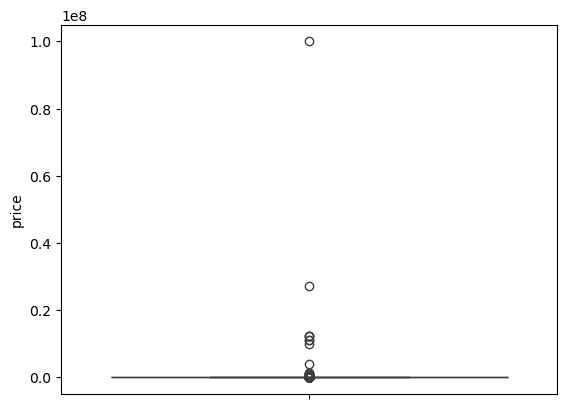

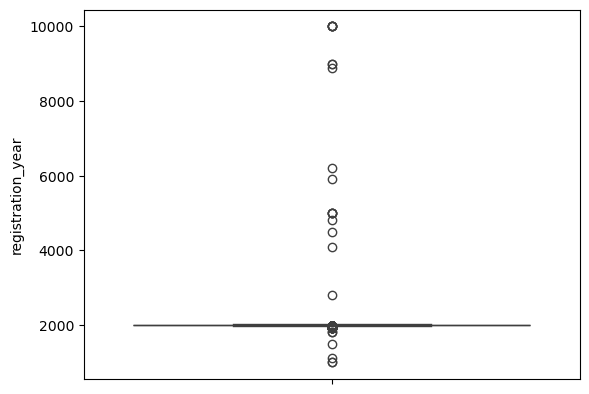

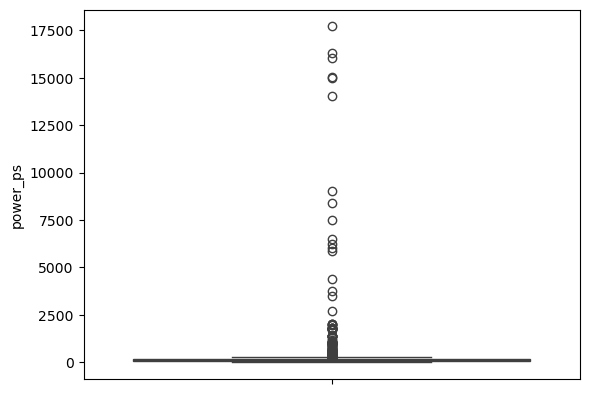

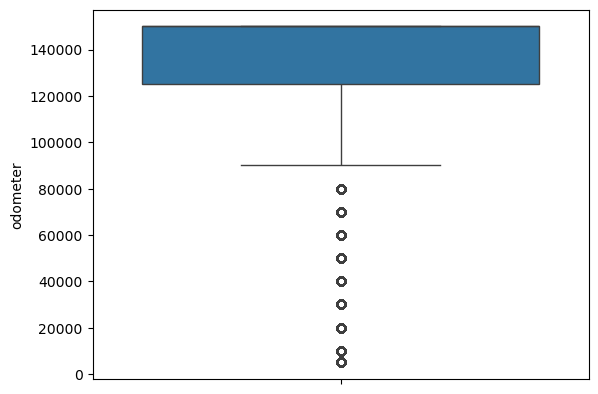

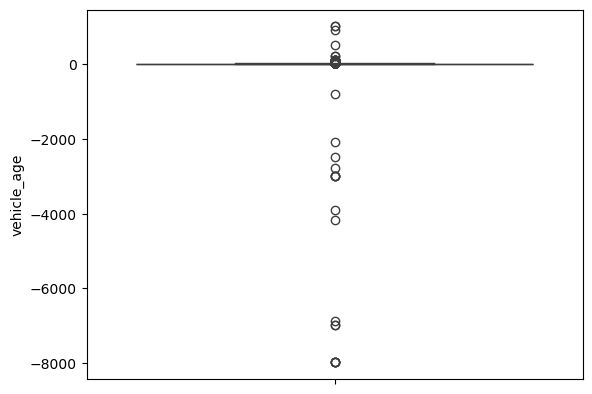

In [16]:
for col in df.select_dtypes("number").columns:
    sns.boxplot(df[col])
    plt.show()

In [17]:
print(df["price"].value_counts().sort_index(ascending=False).head(20))

price
99999999    1
27322222    1
12345678    3
11111111    2
10000000    1
3890000     1
1300000     1
1234566     1
999999      2
999990      1
350000      1
345000      1
299000      1
295000      1
265000      1
259000      1
250000      1
220000      1
198000      1
197000      1
Name: count, dtype: int64


In [18]:
print(df["price"].value_counts().sort_index(ascending=True).head(20))

price
0     1421
1      156
2        3
3        1
5        2
8        1
9        1
10       7
11       2
12       3
13       2
14       1
15       2
17       3
18       1
20       4
25       5
29       1
30       7
35       1
Name: count, dtype: int64


In [19]:
print(df["registration_year"].value_counts().sort_index(ascending=False).head(20))

registration_year
9999       4
9996       1
9000       2
8888       1
6200       1
5911       1
5000       4
4800       1
4500       1
4100       1
2800       1
2019       3
2018     492
2017    1453
2016    1316
2015     399
2014     666
2013     806
2012    1323
2011    1634
Name: count, dtype: int64


In [20]:
print(df["registration_year"].value_counts().sort_index(ascending=True).head(20))

registration_year
1000    1
1001    1
1111    1
1500    1
1800    2
1910    9
1927    1
1929    1
1931    1
1934    2
1937    4
1938    1
1939    1
1941    2
1943    1
1948    1
1950    3
1951    2
1952    1
1953    1
Name: count, dtype: int64


In [21]:

print(df["power_ps"].value_counts().sort_index(ascending=False).head(20))

print(df["power_ps"].value_counts().sort_index(ascending=True).head(20))

power_ps
17700    1
16312    1
16011    1
15016    1
15001    1
14009    1
9011     1
8404     1
7511     1
6512     1
6226     1
6045     1
5867     1
4400     1
3750     1
3500     1
2729     1
2018     1
1998     2
1988     1
Name: count, dtype: int64
power_ps
0     5500
1        5
2        2
3        3
4        4
5       13
6        3
8        2
9        1
10       3
11       4
12       1
14       1
15       5
16       1
18       6
19       3
20       4
21       1
23       4
Name: count, dtype: int64


In [22]:
# Removing price outliers (keeping $500 to $350,000)
df = df[df["price"].between(500, 350000)]

# Removing year outliers (keeping 1950 to 2016)
df = df[df["registration_year"].between(1950, 2016)]
df = df[df["power_ps"].between(50, 1000)]

In [23]:
# Renaming odometer to indicate the unit
df.rename(columns={'odometer': 'odometer_km'}, inplace=True)

# 3. Translate German terms to English 
gearbox_map = {'manuell': 'manual', 'automatik': 'automatic'}
unrepaired_map = {'nein': 'no', 'ja': 'yes'}

df['gearbox'] = df['gearbox'].map(gearbox_map)
df['unrepaired_damage'] = df['unrepaired_damage'].map(unrepaired_map)

print(df.head())

   price vehicle_type  registration_year    gearbox  power_ps    model  \
0   5000          bus               2004     manual       158   andere   
1   8500    limousine               1997  automatic       286      7er   
2   8990    limousine               2009     manual       102     golf   
3   4350   kleinwagen               2007  automatic        71   fortwo   
5   7900          bus               2006  automatic       150  voyager   

   odometer_km fuel_type       brand unrepaired_damage  vehicle_age  
0       150000       lpg     peugeot                no           12  
1       150000    benzin         bmw                no           19  
2        70000    benzin  volkswagen                no            7  
3        70000    benzin       smart                no            9  
5       150000    diesel    chrysler               NaN           10  


In [24]:
df.isnull().sum()

price                   0
vehicle_type         1111
registration_year       0
gearbox               578
power_ps                0
model                1351
odometer_km             0
fuel_type            1733
brand                   0
unrepaired_damage    4983
vehicle_age             0
dtype: int64

In [25]:
df = df.dropna(subset = ["gearbox", "fuel_type", "vehicle_type"])

In [26]:
df["unrepaired_damage"] = df["unrepaired_damage"].fillna("unknown")

In [27]:
df.isnull().sum()

price                  0
vehicle_type           0
registration_year      0
gearbox                0
power_ps               0
model                949
odometer_km            0
fuel_type              0
brand                  0
unrepaired_damage      0
vehicle_age            0
dtype: int64

# EDA

In [28]:
df.head()

,price,vehicle_type,registration_year,gearbox,power_ps,model,odometer_km,fuel_type,brand,unrepaired_damage,vehicle_age
0,5000,bus,2004,manual,158,andere,150000,lpg,peugeot,no,12
1,8500,limousine,1997,automatic,286,7er,150000,benzin,bmw,no,19
2,8990,limousine,2009,manual,102,golf,70000,benzin,volkswagen,no,7
3,4350,kleinwagen,2007,automatic,71,fortwo,70000,benzin,smart,no,9
5,7900,bus,2006,automatic,150,voyager,150000,diesel,chrysler,unknown,10


In [29]:
df.describe()

,price,registration_year,power_ps,odometer_km,vehicle_age
count,36479.000000,36479.000000,36479.000000,36479.000000,36479.000000
mean,6911.540174,2003.489131,131.524658,124414.594698,12.510869
std,9605.227768,6.330096,63.177021,39634.402228,6.330096
min,500.000000,1950.000000,50.000000,5000.000000,0.000000
25%,1750.000000,2000.000000,90.000000,100000.000000,8.000000
50%,3990.000000,2004.000000,120.000000,150000.000000,12.000000
75%,8800.000000,2008.000000,160.000000,150000.000000,16.000000
max,350000.000000,2016.000000,1000.000000,150000.000000,66.000000


In [30]:
cat_cols = df.drop("model", axis = 1).select_dtypes("str")
num_cols = df.select_dtypes("number")

In [31]:
for col in cat_cols:
    print(col)
    print(len(df[col].unique()))

vehicle_type
8
gearbox
2
fuel_type
7
brand
40
unrepaired_damage
3


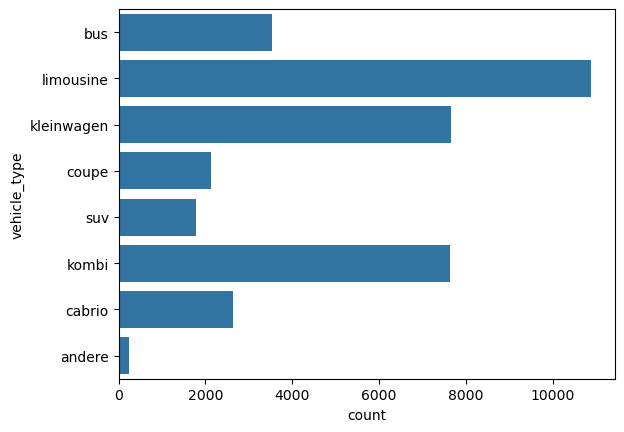

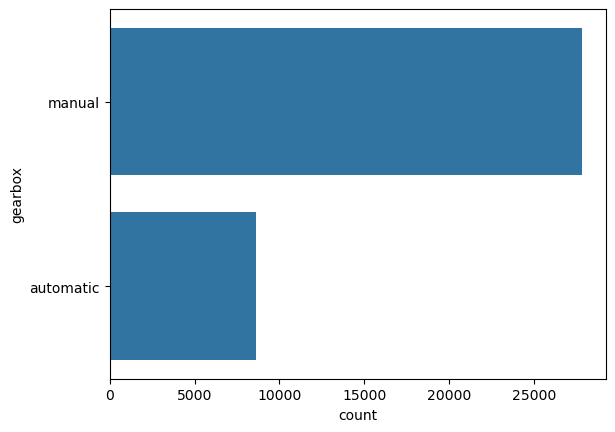

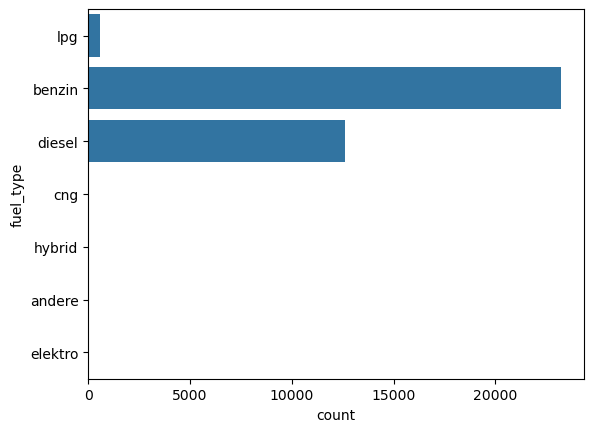

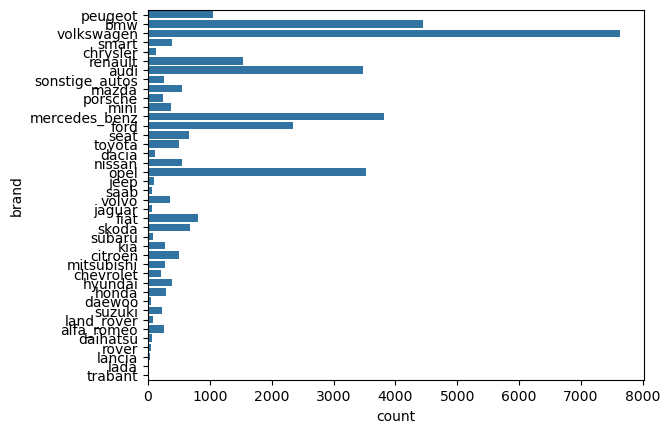

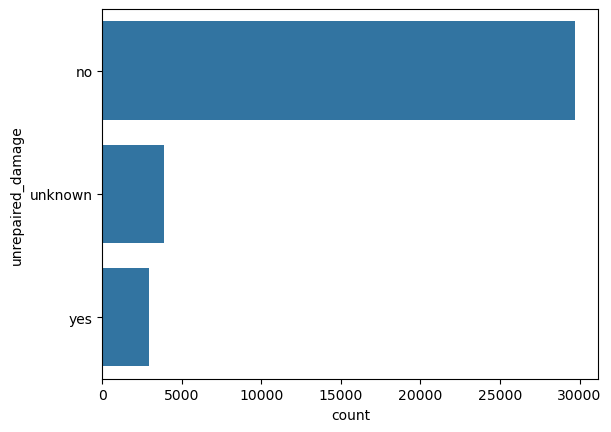

In [32]:
for col in cat_cols:
    sns.countplot(df[col])
    plt.show()

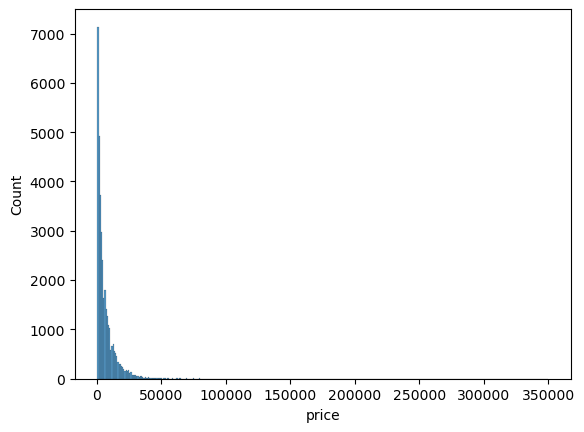

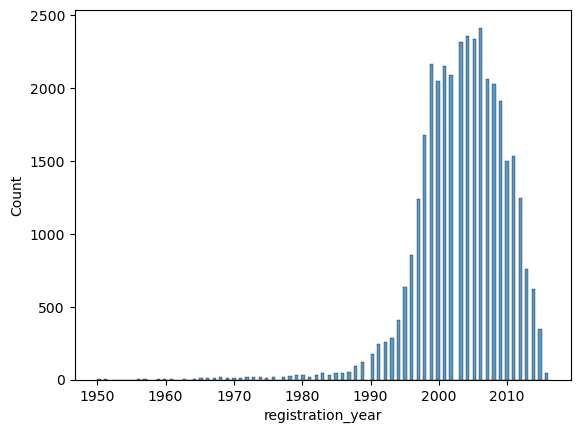

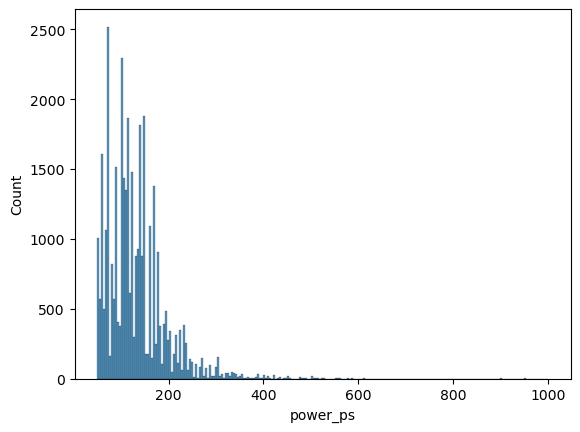

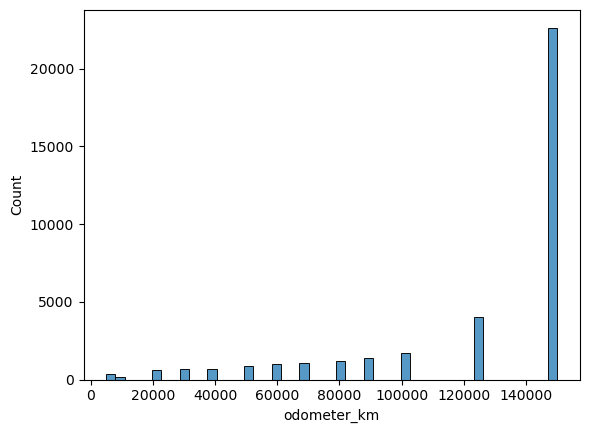

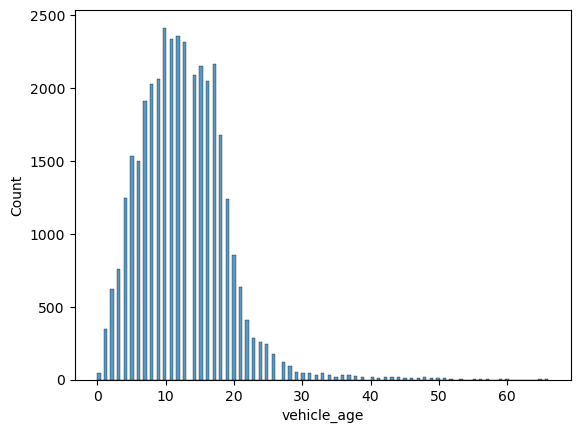

In [33]:
for col in num_cols:
    sns.histplot(df[col])
    plt.show()

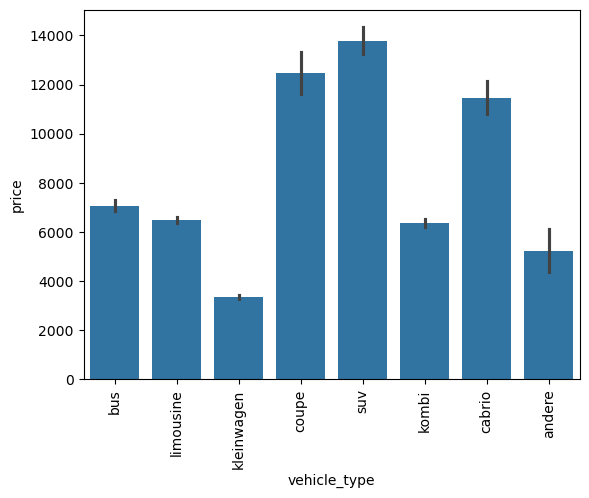

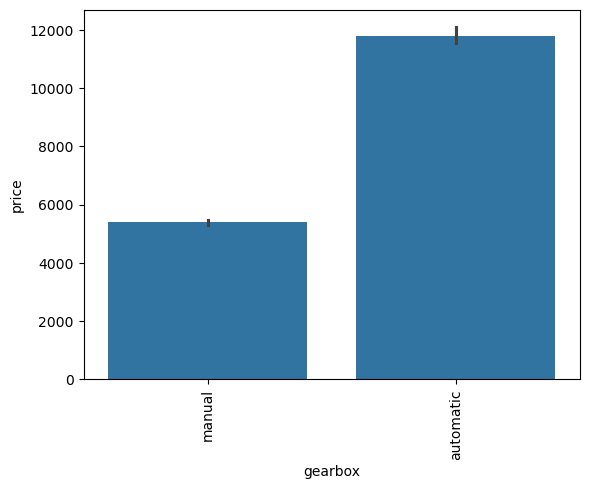

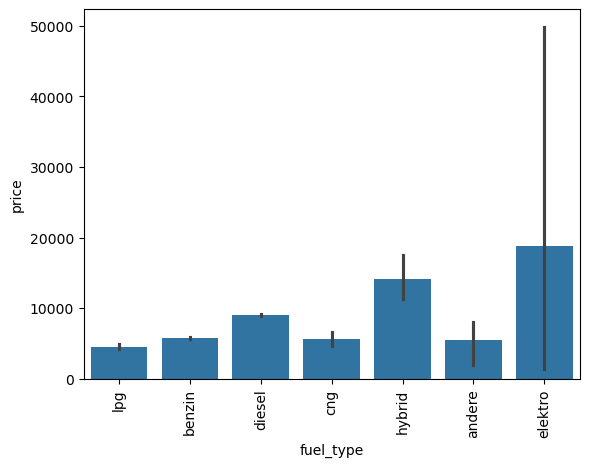

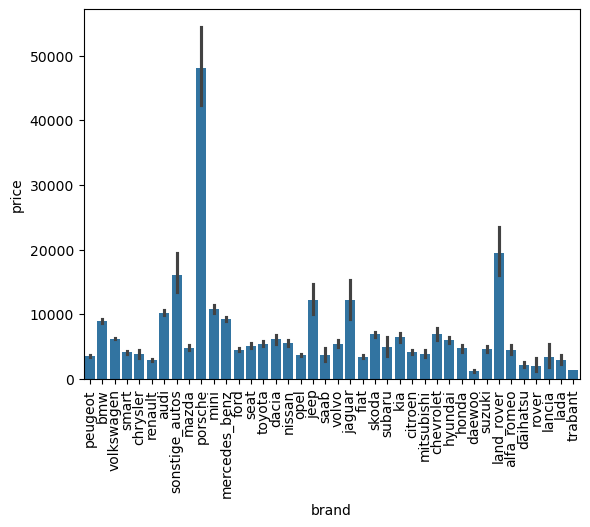

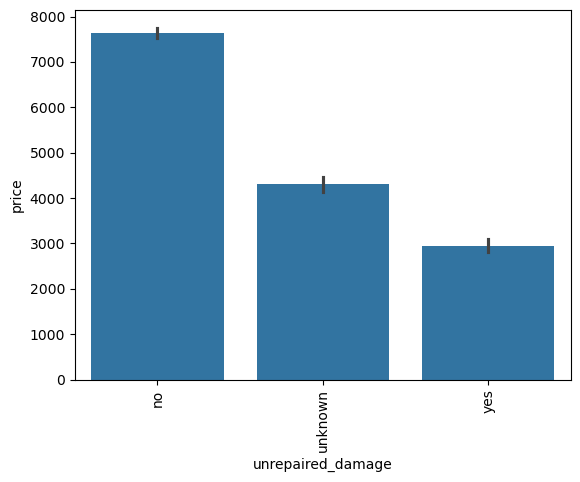

In [34]:
for col in cat_cols:
    sns.barplot(y = df["price"], x = df[col])
    plt.xticks(rotation=90)
    plt.show()

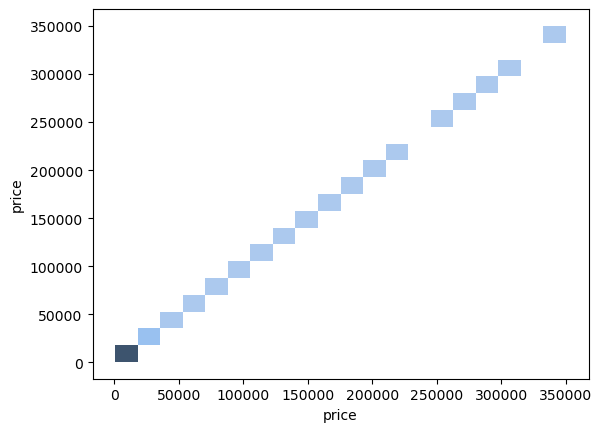

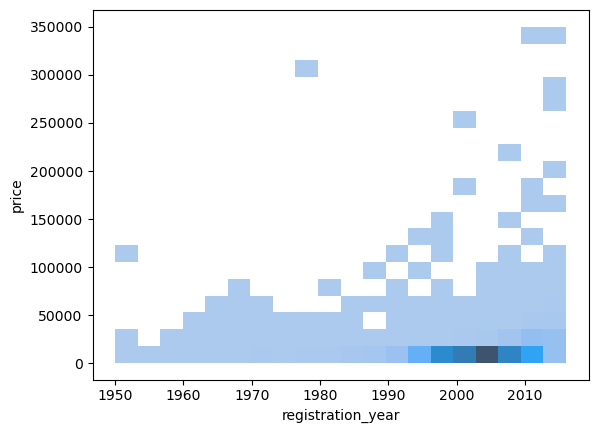

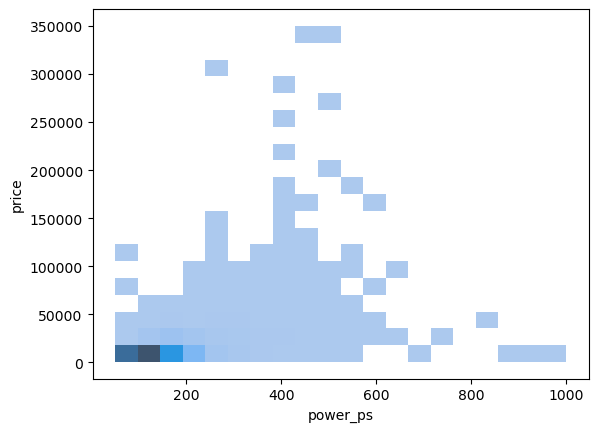

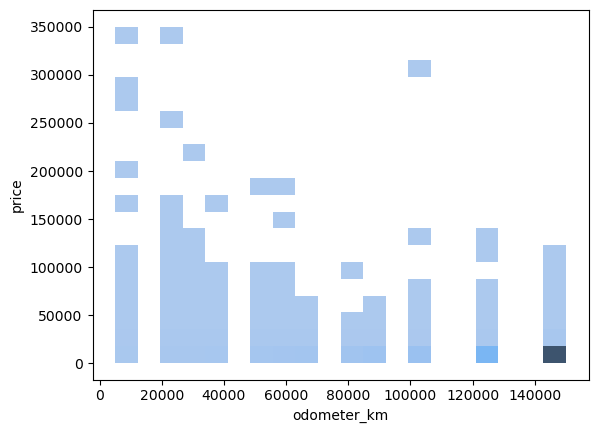

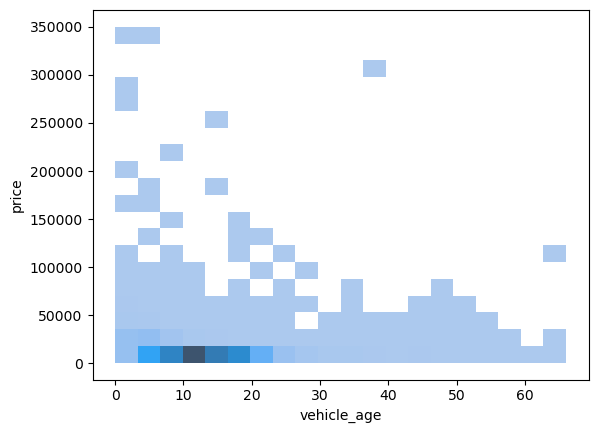

In [35]:
def num_plotter(data, target):
    for col in data.select_dtypes(["int", "float"]):
        sns.histplot(data=data, x=col, y=target, bins=20
                   )
        plt.show()
        
num_plotter(df, "price")

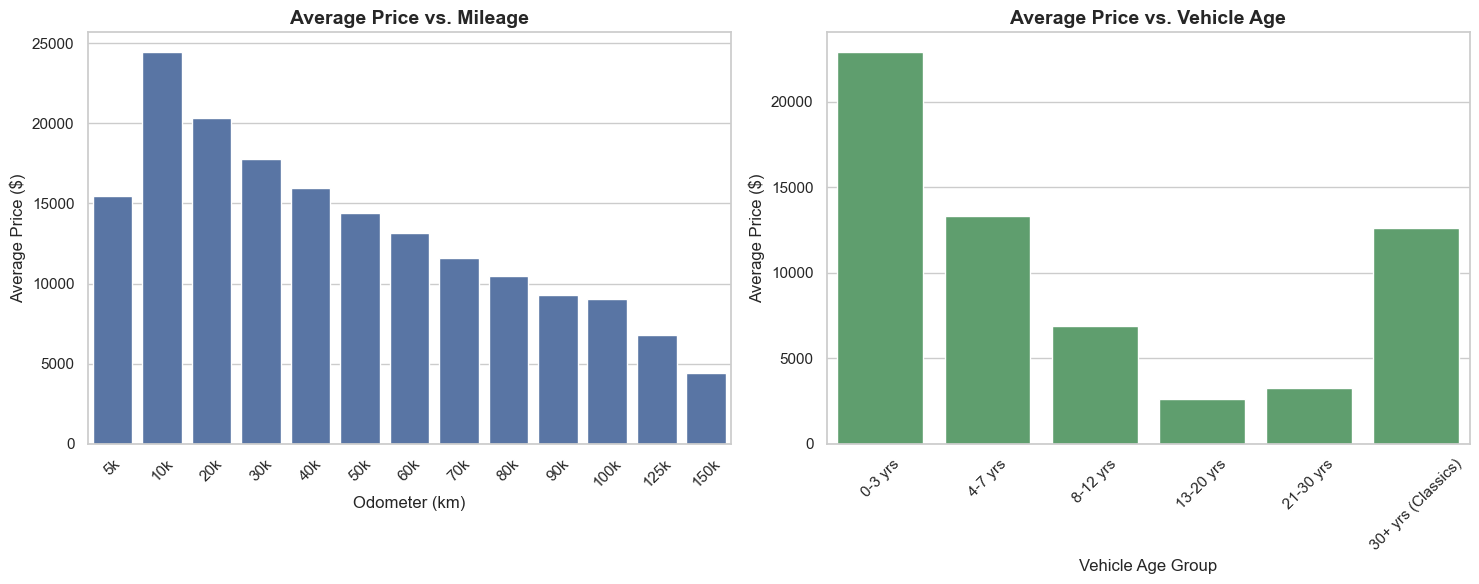

In [36]:
###### Set up plotting environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Price vs Mileage
mileage_price = df.groupby('odometer_km')['price'].mean().reset_index()
sns.barplot(data=mileage_price, x='odometer_km', y='price', color='#4C72B0', ax=axes[0])
axes[0].set_title('Average Price vs. Mileage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Odometer (km)', fontsize=12)
axes[0].set_ylabel('Average Price ($)', fontsize=12)

# Format x-axis labels to look like "5k", "150k" etc.
labels = [f"{int(x/1000)}k" if x >= 1000 else int(x) for x in mileage_price['odometer_km']]
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=45)

# Plot 2: Average Price vs Vehicle Age (Binned)
# We create logical age groupings to make the trend visible
bins = [-1, 3, 7, 12, 20, 30, 70]
age_labels = ['0-3 yrs', '4-7 yrs', '8-12 yrs', '13-20 yrs', '21-30 yrs', '30+ yrs (Classics)']
df['age_group'] = pd.cut(df['vehicle_age'], bins=bins, labels=age_labels)

age_price = df.groupby('age_group', observed=False)['price'].mean().reset_index()
sns.barplot(data=age_price, x='age_group', y='price', color='#55A868', ax=axes[1])
axes[1].set_title('Average Price vs. Vehicle Age', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vehicle Age Group', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Adjust layout and save the image
plt.tight_layout()
plt.savefig('depreciation_bar_charts.png', dpi=300)
plt.show()

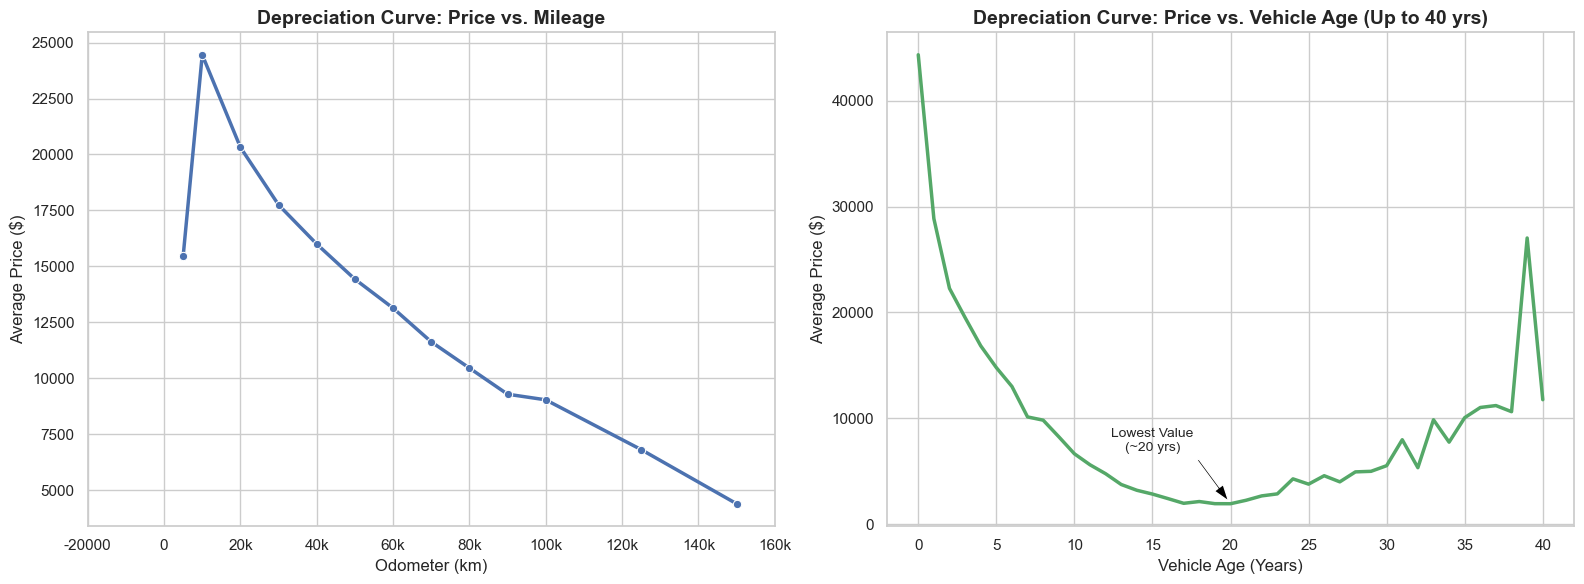

In [37]:

# Set up plotting environment
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Depreciation Curve by Mileage
# Using lineplot to show the continuous trend of mean prices
sns.lineplot(data=df, x='odometer_km', y='price', color='#4C72B0', ax=axes[0], errorbar=None, linewidth=2.5, marker='o')
axes[0].set_title('Depreciation Curve: Price vs. Mileage', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Odometer (km)', fontsize=12)
axes[0].set_ylabel('Average Price ($)', fontsize=12)

# Format x-axis labels
ticks = axes[0].get_xticks()
axes[0].set_xticks(ticks)
axes[0].set_xticklabels([f"{int(x/1000)}k" if x>=1000 else str(int(x)) for x in ticks])

# Plot 2: Depreciation Curve by Vehicle Age
# Filter to vehicles up to 40 years old to keep the curve smooth and focused
df_age_filtered = df[df['vehicle_age'] <= 40]
sns.lineplot(data=df_age_filtered, x='vehicle_age', y='price', color='#55A868', ax=axes[1], errorbar=None, linewidth=2.5)
axes[1].set_title('Depreciation Curve: Price vs. Vehicle Age (Up to 40 yrs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vehicle Age (Years)', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)

# Add an annotation pointing to the lowest value before classic rebound
min_price_age = df_age_filtered.groupby('vehicle_age')['price'].mean().idxmin()
min_price_val = df_age_filtered.groupby('vehicle_age')['price'].mean().min()
axes[1].annotate(f'Lowest Value\n(~{int(min_price_age)} yrs)', 
                 xy=(min_price_age, min_price_val), 
                 xytext=(min_price_age - 5, min_price_val + 5000),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
                 fontsize=10, ha='center')

plt.tight_layout()
plt.savefig('depreciation_curves.png', dpi=300)
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_17276\2527549819.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_price, x='brand', y='price', palette='viridis', ax=axes[0, 0])
C:\Users\USER\AppData\Local\Temp\ipykernel_17276\2527549819.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retention_df, x='brand', y='retention_pct', palette='magma', ax=axes[1, 1])


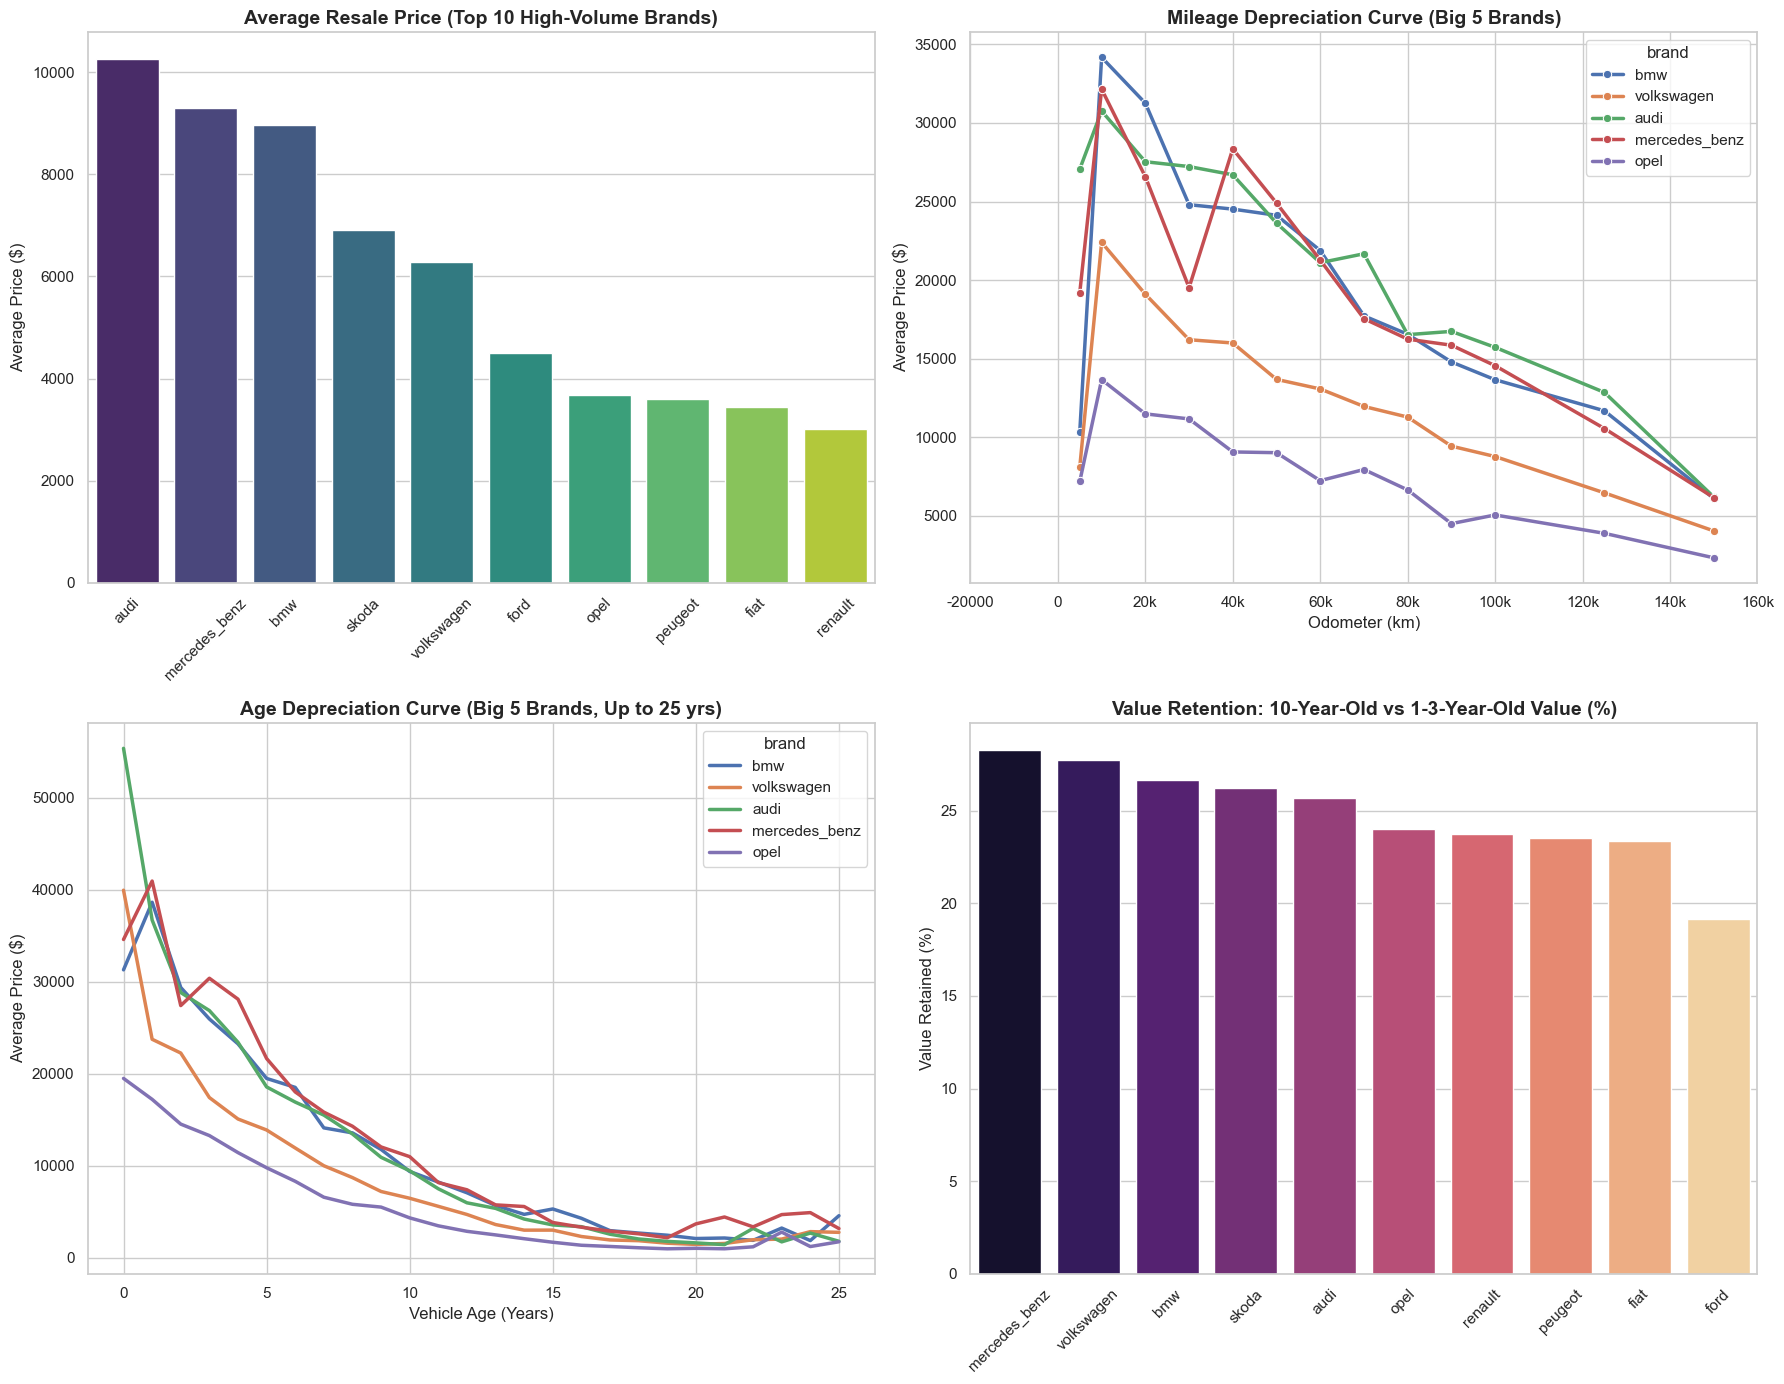

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Identify the Top 10 High-Volume Brands for statistical significance
top_10_brands = df['brand'].value_counts().head(10).index.tolist()
df_top_brands = df[df['brand'].isin(top_10_brands)]

# Set up the 2x2 plotting grid
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ==========================================
# Plot 1: Average Price by Brand (Top 10)
# ==========================================
avg_price = df_top_brands.groupby('brand')['price'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_price, x='brand', y='price', palette='viridis', ax=axes[0, 0])

axes[0, 0].set_title('Average Resale Price (Top 10 High-Volume Brands)', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Average Price ($)', fontsize=12)
axes[0, 0].set_xlabel('')

# ==========================================
# Plot 2: Mileage Depreciation (Big 5 Brands)
# ==========================================
# Isolate the top 5 (VW, BMW, Opel, Mercedes, Audi) to keep the line chart readable
top_5_brands = top_10_brands[:5] 
df_top_5 = df[df['brand'].isin(top_5_brands)]

sns.lineplot(data=df_top_5, x='odometer_km', y='price', hue='brand', ax=axes[0, 1], marker='o', errorbar=None, linewidth=2.5)

axes[0, 1].set_title('Mileage Depreciation Curve (Big 5 Brands)', fontsize=14, fontweight='bold')
# Format x-axis to show 'k' instead of full zeros
ticks = axes[0, 1].get_xticks()
axes[0, 1].set_xticks(ticks)
axes[0, 1].set_xticklabels([f"{int(x/1000)}k" if x>=1000 else str(int(x)) for x in ticks])
axes[0, 1].set_ylabel('Average Price ($)', fontsize=12)
axes[0, 1].set_xlabel('Odometer (km)', fontsize=12)

# ==========================================
# Plot 3: Age Depreciation (Big 5 Brands)
# ==========================================
# Filter to cars <= 25 years old to avoid classic car spikes skewing the standard depreciation view
df_top_5_age = df_top_5[df_top_5['vehicle_age'] <= 25]

sns.lineplot(data=df_top_5_age, x='vehicle_age', y='price', hue='brand', ax=axes[1, 0], errorbar=None, linewidth=2.5)

axes[1, 0].set_title('Age Depreciation Curve (Big 5 Brands, Up to 25 yrs)', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Average Price ($)', fontsize=12)
axes[1, 0].set_xlabel('Vehicle Age (Years)', fontsize=12)

# ==========================================
# Plot 4: Value Retention (% after 10 Years)
# ==========================================
retention_data = []

# Calculate retention for each of the top 10 brands
for brand in top_10_brands:
    brand_df = df[df['brand'] == brand]
    
    # Baseline: Average price of "nearly new" cars (1-3 years old)
    new_price = brand_df[(brand_df['vehicle_age'] >= 1) & (brand_df['vehicle_age'] <= 3)]['price'].mean()
    # Depreciated: Average price of 10-12 year old cars
    old_price = brand_df[(brand_df['vehicle_age'] >= 10) & (brand_df['vehicle_age'] <= 12)]['price'].mean()
    
    if pd.notna(new_price) and pd.notna(old_price) and new_price > 0:
        retention = (old_price / new_price) * 100
        retention_data.append({'brand': brand, 'retention_pct': retention})

# Convert to DataFrame and sort by highest retention
retention_df = pd.DataFrame(retention_data).sort_values(by='retention_pct', ascending=False)

sns.barplot(data=retention_df, x='brand', y='retention_pct', palette='magma', ax=axes[1, 1])

axes[1, 1].set_title('Value Retention: 10-Year-Old vs 1-3-Year-Old Value (%)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Value Retained (%)', fontsize=12)
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

# ==========================================
# Final Layout Adjustments
# ==========================================
plt.tight_layout()
plt.show()

In [39]:
df['brand'].value_counts()

brand
volkswagen        7634
bmw               4443
mercedes_benz     3812
opel              3522
audi              3471
ford              2338
renault           1544
peugeot           1057
fiat               816
skoda              673
seat               669
mazda              549
nissan             544
citroen            510
toyota             507
smart              392
hyundai            392
mini               372
volvo              359
honda              286
mitsubishi         283
kia                275
sonstige_autos     263
alfa_romeo         253
porsche            250
suzuki             222
chevrolet          216
chrysler           133
dacia              108
jeep                94
land_rover          89
subaru              75
daihatsu            64
saab                63
jaguar              60
daewoo              43
rover               43
lancia              36
lada                18
trabant              1
Name: count, dtype: int64

In [40]:

# Filter the dataset to your initial top brands (e.g., anything above 250 counts)
top_brands = df['brand'].value_counts()[df['brand'].value_counts() >= 250].index
df_filtered = df[df['brand'].isin(top_brands)]

# Create a crosstab to see the count of cars per brand, per age
age_distribution = pd.crosstab(df_filtered['brand'], df_filtered['vehicle_age'])
print(age_distribution)

vehicle_age     0   1    2    3    4    5    6    7    8    9   ...  51  52  \
brand                                                           ...           
alfa_romeo       0   2    0    0    1    4    6   12   10   15  ...   0   0   
audi             7  52  117   84  139  196  146  206  244  227  ...   0   0   
bmw              3  38   42   51  116  194  197  206  290  284  ...   0   0   
citroen          1   4    6    9   12   25   37   39   34   37  ...   0   0   
fiat             0   5   16   16   26   37   45   67   47   48  ...   0   0   
ford             1  31   30   47   60   73   83  143  126  105  ...   4   0   
honda            0   1    1    3    4    9    9   17   21   11  ...   0   0   
hyundai          0   8   16   24   37   36   29   24   35   33  ...   0   0   
kia              0   3   14   11   25   12   18   17   19   22  ...   0   0   
mazda            0   6    8    7   11   18   14   15   28   33  ...   0   0   
mercedes_benz    3  16   39   83  104  148  141  153

In [41]:
# Keep only standard used cars (e.g., 20 years old or newer
df_clean = df_filtered[df_filtered['vehicle_age'] <= 20].copy()

In [42]:
# Keep only standard used cars (e.g., 20 years old or newer)
df_clean = df_filtered[df_filtered['vehicle_age'] <= 20].copy()

In [43]:
df_clean

,price,vehicle_type,registration_year,gearbox,power_ps,model,odometer_km,fuel_type,brand,unrepaired_damage,vehicle_age,age_group
0,5000,bus,2004,manual,158,andere,150000,lpg,peugeot,no,12,8-12 yrs
1,8500,limousine,1997,automatic,286,7er,150000,benzin,bmw,no,19,13-20 yrs
2,8990,limousine,2009,manual,102,golf,70000,benzin,volkswagen,no,7,4-7 yrs
3,4350,kleinwagen,2007,automatic,71,fortwo,70000,benzin,smart,no,9,8-12 yrs
7,1990,limousine,1998,manual,90,golf,150000,diesel,volkswagen,no,18,13-20 yrs
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,24900,limousine,2011,automatic,239,q5,100000,diesel,audi,no,5,4-7 yrs
49996,1980,cabrio,1996,manual,75,astra,150000,benzin,opel,no,20,13-20 yrs
49997,13200,cabrio,2014,automatic,69,500,5000,benzin,fiat,no,2,0-3 yrs
49998,22900,kombi,2013,manual,150,a3,40000,diesel,audi,no,3,0-3 yrs


In [44]:
# Create bins for the typical lifecycle stages of a car
bins = [-1, 3, 7, 12, 20] 
labels = ['0-3 Years (New/Lease Return)', 
          '4-7 Years (Mid-Life)', 
          '8-12 Years (Older)', 
          '13-20 Years (End of Life)']

df_clean['age_bracket'] = pd.cut(df_clean['vehicle_age'], bins=bins, labels=labels)

In [45]:
pd.crosstab(df_clean['brand'], df_clean['age_group'])

age_group,0-3 yrs,4-7 yrs,8-12 yrs,13-20 yrs
brand,,,,
alfa_romeo,2,23,75,131
audi,260,687,1129,1138
bmw,134,713,1466,1744
citroen,20,113,209,155
fiat,37,175,238,340
ford,109,359,768,997
honda,5,39,76,118
hyundai,48,126,139,77
kia,28,72,130,43


In [46]:
df_clean.to_csv("clean_autos.csv")

In [47]:
df_clean.pivot_table(values = "price", index = "brand", columns = "age_group")

age_group,0-3 yrs,4-7 yrs,8-12 yrs,13-20 yrs
brand,,,,
alfa_romeo,33675.000000,8689.130435,5055.533333,1841.351145
audi,30486.046154,18274.000000,9555.300266,3279.806678
bmw,30748.201493,18273.976157,9940.556617,3888.379587
citroen,11430.950000,7390.938053,3717.330144,1427.638710
fiat,10780.864865,6038.240000,3251.642857,1322.814706
ford,17038.724771,8544.197772,4131.917969,1541.606820
honda,14997.600000,10534.179487,6107.157895,2296.211864
hyundai,12250.083333,8336.571429,4054.395683,1787.870130
kia,17601.928571,9536.500000,3996.246154,1721.023256


In [48]:
corr_matrix = df_clean[['price', 'vehicle_age', 'odometer_km']].corr(method='spearman')
corr_matrix

,price,vehicle_age,odometer_km
price,1.000000,-0.796251,-0.462064
vehicle_age,-0.796251,1.000000,0.535917
odometer_km,-0.462064,0.535917,1.000000


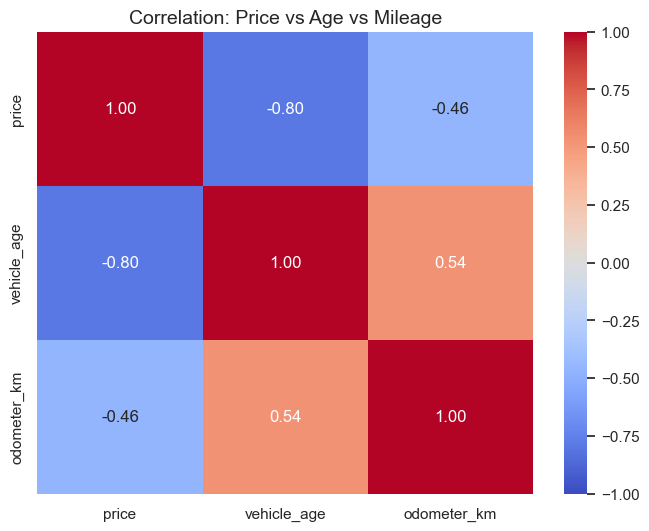

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True,          # Shows the exact mathematical weights inside the squares
            cmap='coolwarm',     # Blue for negative correlation, Red for positive
            fmt=".2f",           # Rounds to 2 decimal places
            vmin=-1, vmax=1)     # Locks the scale from -1 to 1
            
plt.title("Correlation: Price vs Age vs Mileage", fontsize=14)
plt.show()

In [50]:

retention_df = df_clean.pivot_table(index='brand', 
                                    columns='age_group', 
                                    values='price', 
                                    aggfunc='median')

#Calculating the Overall Retention Percentage
# Formula: (Oldest Price / Newest Price) * 100
retention_df['Retention_Percentage'] = (retention_df['13-20 yrs'] / retention_df['0-3 yrs']) * 100

# 3. Clean and Sort
# Dropping brands that didn't have enough data in the 0-3 bracket (resulting in NaN)
retention_df = retention_df.dropna(subset=['Retention_Percentage'])
retention_df = retention_df.sort_values(by='Retention_Percentage', ascending=False)

print(retention_df[['Retention_Percentage']])

age_group       Retention_Percentage
brand                               
smart                      24.878110
mini                       20.660116
sonstige_autos             19.987234
porsche                    19.433255
mitsubishi                 17.433752
honda                      13.909905
hyundai                    13.729977
skoda                      13.475177
toyota                     12.738710
citroen                    11.167985
mercedes_benz              10.525455
renault                    10.426540
fiat                       10.256410
peugeot                    10.144928
audi                        9.445958
bmw                         9.421643
opel                        9.352518
volkswagen                  9.191646
volvo                       8.300908
nissan                      8.275862
seat                        8.221519
mazda                       7.671233
ford                        7.384615
kia                         7.246587
alfa_romeo                  4.454343


In [51]:
retention_df

age_group,0-3 yrs,4-7 yrs,8-12 yrs,13-20 yrs,Retention_Percentage
brand,,,,,
smart,7999.0,6150.0,3499.5,1990.0,24.878110
mini,19845.0,13200.0,7400.0,4100.0,20.660116
sonstige_autos,23500.0,13650.0,9749.5,4697.0,19.987234
porsche,106750.0,53200.0,26650.0,20745.0,19.433255
mitsubishi,7170.0,9450.0,3549.5,1250.0,17.433752
honda,11499.0,9700.0,5500.0,1599.5,13.909905
hyundai,10925.0,7100.0,3300.0,1500.0,13.729977
skoda,14100.0,8500.0,4500.0,1900.0,13.475177
toyota,15500.0,7750.0,4950.0,1974.5,12.738710


C:\Users\USER\AppData\Local\Temp\ipykernel_17276\2365178695.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=retention_df, x='brand', y='Retention_Percentage', palette='magma')


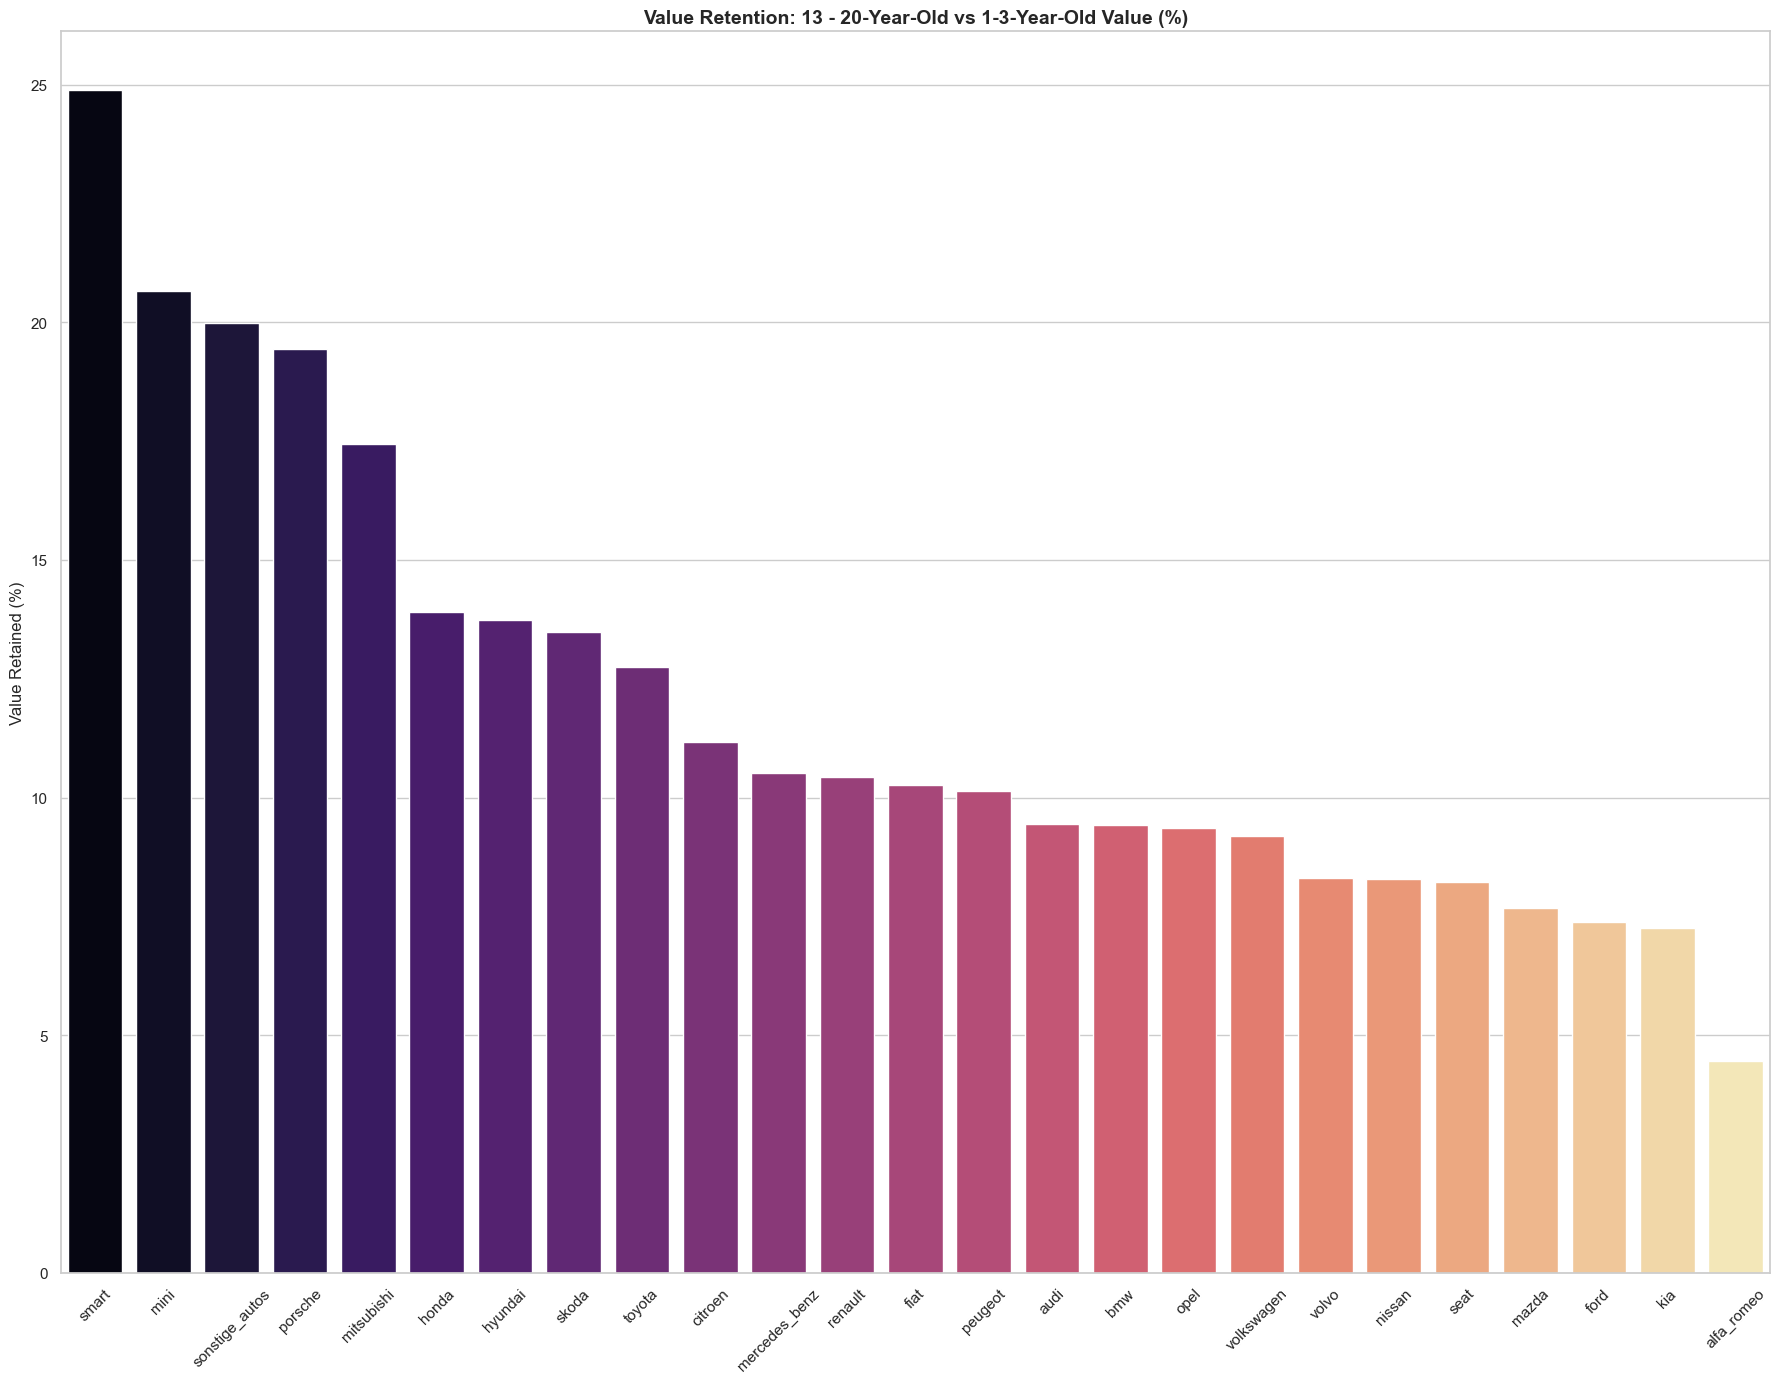

In [52]:
fig, ax = plt.subplots(figsize=(18, 14))
sns.barplot(data=retention_df, x='brand', y='Retention_Percentage', palette='magma')

ax.set_title('Value Retention: 13 - 20-Year-Old vs 1-3-Year-Old Value (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Value Retained (%)', fontsize=12)
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)

# ==========================================
# Final Layout Adjustments
# ==========================================
plt.tight_layout()
plt.show()

# Pricing Estimator

In [53]:
from sklearn.ensemble import IsolationForest

# 1. Define the features to check for multivariate anomalies
anomaly_features = ['price', 'vehicle_age', 'odometer_km']

# 2. Initialize the model
# Setting contamination=0.02 assumes roughly 2% of the data are hidden errors. 
iso_forest = IsolationForest(contamination=0.02, random_state=42)

# 3. Fit the model and predict anomalies
# It returns 1 for normal data points, and -1 for anomalies
df_clean['anomaly_score'] = iso_forest.fit_predict(df_clean[anomaly_features])

# 4. Filter out the anomalies and drop the temporary score column
df_final = df_clean[df_clean['anomaly_score'] == 1].drop(columns=['anomaly_score']).copy()

print(f"Original listings: {len(df_clean)}")
print(f"Cleaned listings: {len(df_final)}")
print(f"Anomalies removed: {len(df_clean) - len(df_final)}")

Original listings: 32566
Cleaned listings: 31917
Anomalies removed: 649


In [54]:
df_clean[df_clean['anomaly_score'] == -1]

,price,vehicle_type,registration_year,gearbox,power_ps,model,odometer_km,fuel_type,brand,unrepaired_damage,vehicle_age,age_group,age_bracket,anomaly_score
21,41500,cabrio,2004,manual,320,911,150000,benzin,porsche,no,12,8-12 yrs,8-12 Years (Older),-1
22,25450,cabrio,2015,manual,184,cooper,10000,benzin,mini,no,1,0-3 yrs,0-3 Years (New/Lease Return),-1
24,48500,limousine,2014,automatic,306,5er,30000,benzin,bmw,no,2,0-3 yrs,0-3 Years (New/Lease Return),-1
49,56000,coupe,2012,automatic,435,cl,60000,benzin,mercedes_benz,no,4,4-7 yrs,4-7 Years (Mid-Life),-1
76,31999,limousine,2016,manual,136,3er,5000,benzin,bmw,unknown,0,0-3 yrs,0-3 Years (New/Lease Return),-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49437,30700,suv,2015,manual,175,cx_reihe,5000,diesel,mazda,no,1,0-3 yrs,0-3 Years (New/Lease Return),-1
49484,2000,limousine,2001,automatic,197,c_klasse,5000,benzin,mercedes_benz,yes,15,13-20 yrs,13-20 Years (End of Life),-1
49668,145000,coupe,1998,manual,286,911,60000,benzin,porsche,no,18,13-20 yrs,13-20 Years (End of Life),-1
49701,500,limousine,1996,manual,150,a4,30000,benzin,audi,yes,20,13-20 yrs,13-20 Years (End of Life),-1


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# 1. Separate your features into lists based on how they need to be processed
numeric_features = ['vehicle_age', 'odometer_km', 'power_ps']
categorical_features = ['brand', 'vehicle_type', 'gearbox', 'fuel_type', 'unrepaired_damage']

X = df_final[numeric_features + categorical_features]
y = df_final['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Build the Numeric Transformer
# Fills missing numbers with the median
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# 3. Build the Categorical Transformer
# Fills missing text with the most frequent value, then One-Hot Encodes
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 4. Combine them into the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', RandomForestRegressor(
        n_estimators=75,      
        max_depth=20,         
        min_samples_leaf=2,  
        random_state=42
    ))
])

print("Training model...")
rf_pipeline.fit(X_train, y_train)


from sklearn.metrics import r2_score
predictions = rf_pipeline.predict(X_test)
print(f"New R-Squared: {r2_score(y_test, predictions):.3f}")


joblib.dump(rf_pipeline, 'car_price_model.pkl', compress=3)
print(" model saved!")

Training model...
New R-Squared: 0.881
Lightweight model saved!


In [56]:
import pandas as pd

def get_price_estimate(brand, age, km, ps, v_type, gearbox, fuel, damage):
    # 1. Package the real-time input into a DataFrame matching your training data
    input_data = pd.DataFrame({
        'brand': [brand],
        'vehicle_age': [age],
        'odometer_km': [km],
        'power_ps': [ps],
        'vehicle_type': [v_type],
        'gearbox': [gearbox],
        'fuel_type': [fuel],
        'unrepaired_damage': [damage]
    })
    
    
    # The pipeline will automatically handle the NaNs, the One-Hot Encoding, and the prediction
    estimated_price = rf_pipeline.predict(input_data)[0]
    
    print("-" * 30)
    print(f"Vehicle: {age}-Year-Old {brand.title()} ({v_type})")
    print(f"Specs: {km:,.0f} km | {ps} PS | {gearbox.title()} | Damage: {damage.title()}")
    print(f"ESTIMATED MARKET VALUE: ${estimated_price:,.2f}")
    print("-" * 30)

# Test it right now with a hypothetical car!
get_price_estimate(brand='volkswagen', age=4, km=65000, ps=150, v_type='limousine', gearbox='automatik', fuel='diesel', damage='nein')

------------------------------
Vehicle: 4-Year-Old Volkswagen (limousine)
Specs: 65,000 km | 150 PS | Automatik | Damage: Nein
ESTIMATED MARKET VALUE: $17,303.65
------------------------------


In [57]:
# Export the clean data to a CSV file without the index column
df_final.to_csv('cleaned_car_pricing_data.csv', index=False)

print("Data exported and ready for Tableau!")

Data exported and ready for Tableau!


In [58]:
retention_df

age_group,0-3 yrs,4-7 yrs,8-12 yrs,13-20 yrs,Retention_Percentage
brand,,,,,
smart,7999.0,6150.0,3499.5,1990.0,24.878110
mini,19845.0,13200.0,7400.0,4100.0,20.660116
sonstige_autos,23500.0,13650.0,9749.5,4697.0,19.987234
porsche,106750.0,53200.0,26650.0,20745.0,19.433255
mitsubishi,7170.0,9450.0,3549.5,1250.0,17.433752
honda,11499.0,9700.0,5500.0,1599.5,13.909905
hyundai,10925.0,7100.0,3300.0,1500.0,13.729977
skoda,14100.0,8500.0,4500.0,1900.0,13.475177
toyota,15500.0,7750.0,4950.0,1974.5,12.738710
